In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score, silhouette_samples


In [27]:
df_one = pd.read_csv("One_Hot_claims_train.csv")
df_one

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density,VehBrand_B1,VehBrand_B10,VehBrand_B11,...,Region_R53,Region_R54,Region_R72,Region_R73,Region_R74,Region_R82,Region_R83,Region_R91,Region_R93,Region_R94
0,0,0.43,7,18,36,95,1054,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0.10,7,17,80,95,598,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0.33,7,3,36,76,4172,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0.56,5,4,73,52,15,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0.27,8,0,37,50,3021,0,0,1,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541411,0,0.20,6,10,32,76,1314,0,0,0,...,0,0,0,0,0,0,0,0,0,0
541412,0,0.06,10,14,34,60,685,0,0,0,...,0,0,1,0,0,0,0,0,0,0
541413,0,0.34,6,8,32,95,242,0,0,0,...,0,0,0,0,0,1,0,0,0,0
541414,0,0.72,9,7,39,72,3301,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [29]:
scaler = StandardScaler()
pca_one_hot = PCA(n_components=3)
X_one_hot = df_one.loc[:, df_one.columns != 'ClaimNb']
X_one_hot_scaled = scaler.fit_transform(X_one_hot)
pca_one_hot.fit(X_one_hot_scaled)
X_one_hot_pca = pca_one_hot.transform(X_one_hot_scaled)



In [30]:
k = 4
kmeans_one_hot = KMeans(n_clusters=k, random_state=42)
kmeans_one_hot.fit(X_one_hot_pca)
labels_one_hot = kmeans_one_hot.labels_  # cluster index for each row
centroids_one_hot = kmeans_one_hot.cluster_centers_

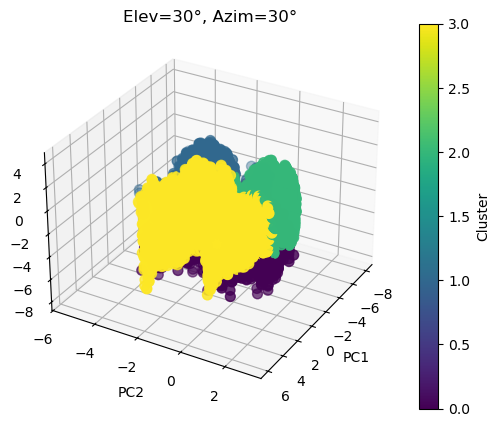

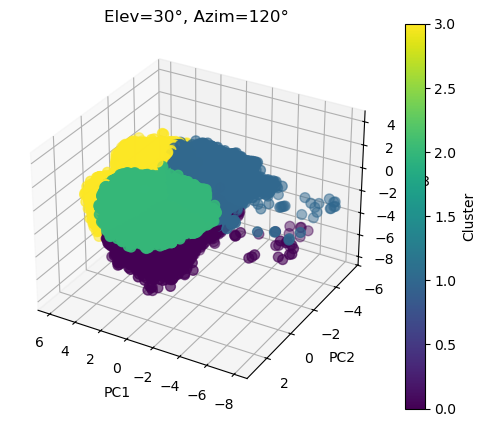

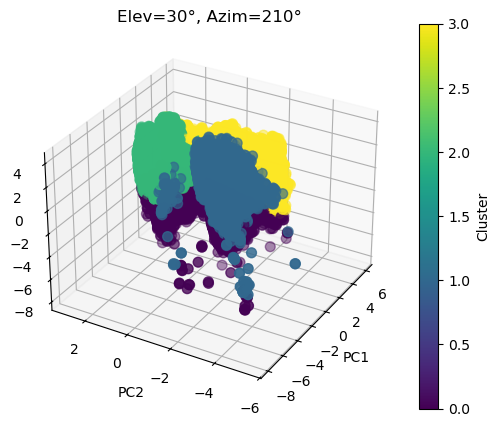

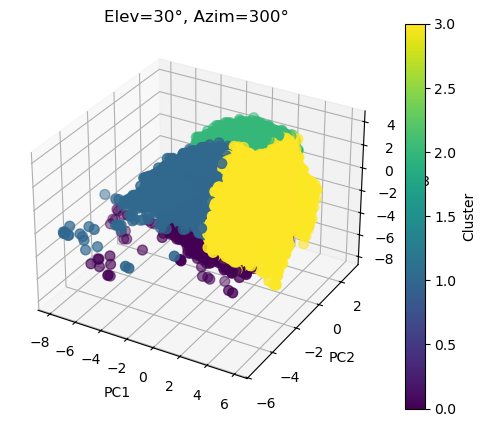

In [ ]:
angles = [(30, 30), (30, 120), (30, 210), (30, 300)]  # (elevation, azimuth) pairs

for i, (elev, azim) in enumerate(angles):
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter(X_one_hot_pca[:, 0], X_one_hot_pca[:, 1], X_one_hot_pca[:, 2],
                         c=labels, cmap='viridis', s=50)
    
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.view_init(elev=elev, azim=azim)  # set viewpoint
    
    plt.title(f'Elev={elev}°, Azim={azim}°')
    plt.colorbar(scatter, ax=ax, label='Cluster')
    plt.show()

In [31]:
scaler = StandardScaler()
pca = PCA(n_components=2)
pca.fit(X_one_hot_scaled)
X_2d_pca = pca.transform(X_one_hot_scaled)

In [32]:
k = 2
kmeans_2d_one_hot = KMeans(n_clusters=k, random_state=42)
kmeans_2d_one_hot.fit(X_2d_pca)
labels_2d_one_hot = kmeans_2d_one_hot.labels_  # cluster index for each row
centroids_2d_one_hot = kmeans_2d_one_hot.cluster_centers_

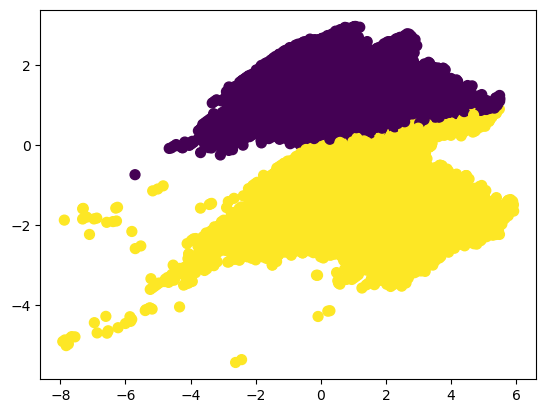

In [33]:
plt.scatter(X_2d_pca[:,0],X_2d_pca[:,1],c=labels_2d_one_hot, cmap='viridis', s=50)

Trying by droppped CSV

In [2]:
df_dropped = pd.read_csv("Dropped_claims_train.csv")
df_dropped

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
0,0,0.43,7,18,36,95,1054
1,0,0.10,7,17,80,95,598
2,0,0.33,7,3,36,76,4172
3,0,0.56,5,4,73,52,15
4,0,0.27,8,0,37,50,3021
...,...,...,...,...,...,...,...
541411,0,0.20,6,10,32,76,1314
541412,0,0.06,10,14,34,60,685
541413,0,0.34,6,8,32,95,242
541414,0,0.72,9,7,39,72,3301


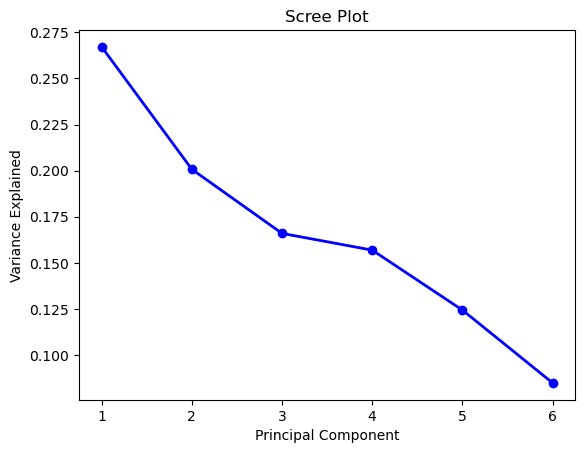

In [110]:
scaler = StandardScaler()
X = df_dropped.loc[:, df_dropped.columns != 'ClaimNb']
X_scaled = scaler.fit_transform(X)
pca = PCA()
pca.fit(X_scaled)
per_var = pca.explained_variance_ratio_ *100

PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()



4 or 5 components

In [3]:
scaler = StandardScaler()
pca = PCA(n_components=2)
X = df_dropped.loc[:, df_dropped.columns != 'ClaimNb']
X_scaled = scaler.fit_transform(X)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

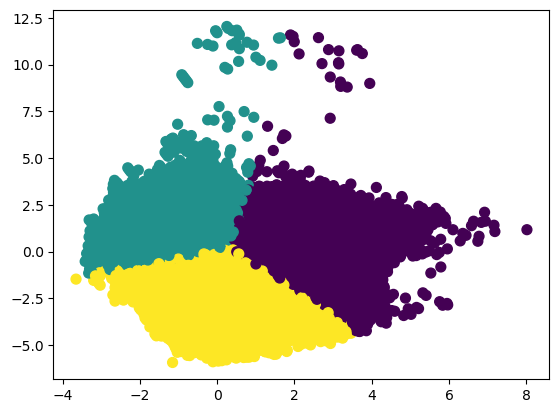

In [19]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_pca)
labels = kmeans.labels_  # cluster index for each row
centroids = kmeans.cluster_centers_
plt.scatter(X_pca[:,0],X_pca[:,1],c=labels, cmap='viridis', s=50)

In [112]:
WCSS = []

for i in range(1,30):
  kmeans_pca = KMeans(n_clusters = i, init = "k-means++", random_state = 42)
  kmeans_pca.fit(X_pca)
  WCSS.append(kmeans_pca.inertia_)

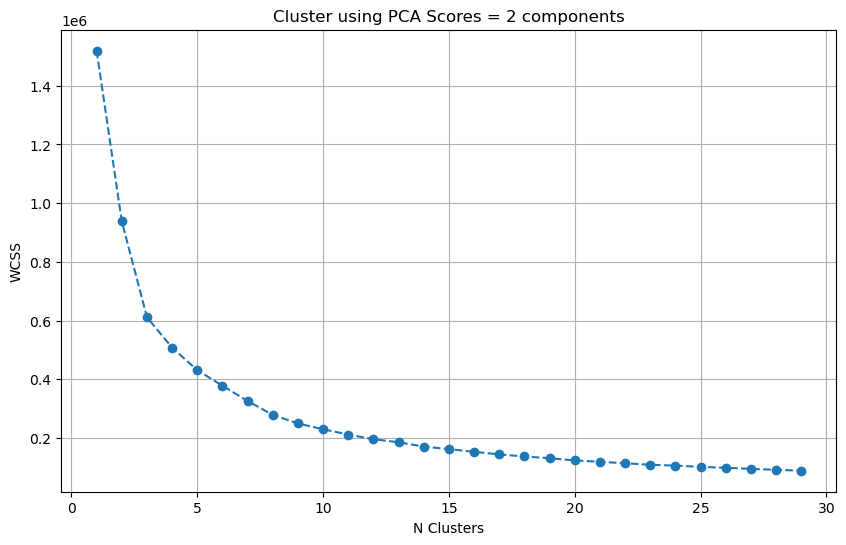

In [113]:
plt.figure(figsize = (10,6))
plt.plot(range(1,30), WCSS, marker = "o", linestyle = "--")
plt.grid()
plt.title("Cluster using PCA Scores = 2 components")
plt.ylabel("WCSS")
plt.xlabel("N Clusters")
plt.show()

In [115]:
sil_scores = {}
sample_size = 10000
for n_clusters in range(2,30):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_pca)
    labels = kmeans.labels_
    sil = silhouette_score(X_pca, labels, sample_size=sample_size, random_state=42)
    sil_scores[n_clusters] = sil
    #avg_sil = np.mean(sil_scores)

max(sil_scores)





29

In [116]:
sil_scores

{2: 0.39194865079898344,
 3: 0.38231477274888714,
 4: 0.3388704280121181,
 5: 0.31690832609706365,
 6: 0.31165676493197597,
 7: 0.31644409442057253,
 8: 0.33287288195989556,
 9: 0.3326362130909389,
 10: 0.3246976911684355,
 11: 0.3219487960379801,
 12: 0.3147174707649231,
 13: 0.3184556123153453,
 14: 0.31992641029404306,
 15: 0.316936734315315,
 16: 0.31705940461179605,
 17: 0.31796731951767626,
 18: 0.31478918872592393,
 19: 0.3147974666654268,
 20: 0.3192896486965977,
 21: 0.31768780565153154,
 22: 0.31752025278365303,
 23: 0.3147657807947755,
 24: 0.3141111561553711,
 25: 0.31503394639864934,
 26: 0.3147103245339026,
 27: 0.317851233142085,
 28: 0.317534254371541,
 29: 0.30965051809820243}

In [117]:
k_max = max(sil_scores, key=sil_scores.get)
print(f"Optimal number of clusters: {k_max} with Silhouette Score: {sil_scores[k_max]:.4f}")


Optimal number of clusters: 2 with Silhouette Score: 0.3919


In [96]:
scaler = StandardScaler()
pca_4n = PCA(n_components=5)
X_4n = df_dropped.loc[:, df_dropped.columns != 'ClaimNb']
X_scaled_4n = scaler.fit_transform(X_4n)
pca_4n.fit(X_scaled_4n)
X_pca_4n = pca_4n.transform(X_scaled_4n)

In [105]:
sil_scores_4n = {}
sample_size = 10000
for n_clusters in range(2,30):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_pca_4n)
    labels = kmeans.labels_
    sil = silhouette_score(X_pca_4n, labels, sample_size=sample_size, random_state=42)
    sil_scores_4n[n_clusters] = sil
    #avg_sil = np.mean(sil_scores)



In [107]:
k_max = max(sil_scores, key=sil_scores_4n.get)
print(f"Optimal number of clusters: {k_max} with Silhouette Score: {sil_scores_4n[k_max]:.4f}")

Optimal number of clusters: 5 with Silhouette Score: 0.2411


In [108]:
sil_scores_4n

{2: 0.23672982641534474,
 3: 0.2190331672373938,
 4: 0.23525881726444173,
 5: 0.24108363351169657,
 6: 0.2250055405226505,
 7: 0.2130662628288242,
 8: 0.2177117037822261,
 9: 0.21387132008131435,
 10: 0.20938891649547486,
 11: 0.20700104144693887,
 12: 0.20756447476882658,
 13: 0.19946845246399314,
 14: 0.19426250663793385,
 15: 0.1917367963655764,
 16: 0.18842152086871553,
 17: 0.18796295143715105,
 18: 0.1849747197544395,
 19: 0.18098042151275986,
 20: 0.17480011489792627,
 21: 0.1783449841756374,
 22: 0.17782415802509147,
 23: 0.17966168848855213,
 24: 0.17345541478555423,
 25: 0.17331625825044694,
 26: 0.1777222110230684,
 27: 0.17622972883807836,
 28: 0.17900196848639488,
 29: 0.17826295193526023}

In [102]:
WCSS = []

for i in range(1,30):
  kmeans_pca = KMeans(n_clusters = i, init = "k-means++", random_state = 42)
  kmeans_pca.fit(X_pca_4n)
  WCSS.append(kmeans_pca.inertia_)

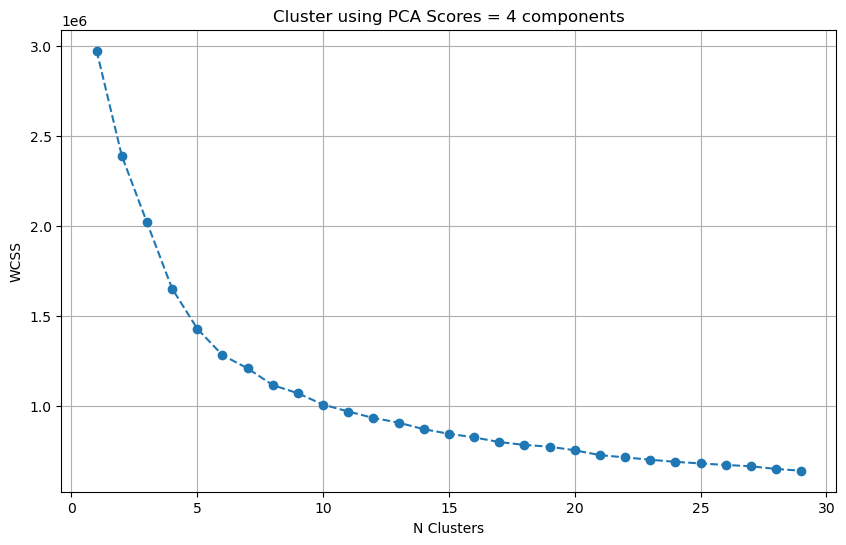

In [111]:
plt.figure(figsize = (10,6))
plt.plot(range(1,30), WCSS, marker = "o", linestyle = "--")
plt.grid()
plt.title("Cluster using PCA Scores = 4 components")
plt.ylabel("WCSS")
plt.xlabel("N Clusters")
plt.show()

In [49]:
pca_3d_dropped = PCA(n_components=3)
X_3d_dropped = df_dropped.loc[:, df_dropped.columns != 'ClaimNb']
X_3d_dropped_scaled = scaler.fit_transform(X_3d_dropped)
pca_3d_dropped.fit(X_3d_dropped_scaled)
X_pca_3d_dropped =pca_3d_dropped.transform(X_3d_dropped_scaled)

In [53]:
sil_scores_3d = {}
sample_size = 10000
for n_clusters in range(2,10):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_pca_3d_dropped)
    labels = kmeans.labels_
    sil = silhouette_score(X_pca_3d_dropped, labels, sample_size=sample_size, random_state=42)
    sil_scores_3d[n_clusters] = sil
    #avg_sil = np.mean(sil_scores)

In [54]:
k_max_3d = max(sil_scores_3d, key=sil_scores_3d.get)
print(f"Optimal number of clusters (3D PCA): {k_max_3d} with Silhouette Score: {sil_scores_3d[k_max_3d]:.4f}")

Optimal number of clusters (3D PCA): 2 with Silhouette Score: 0.3001


### Silhouette Score

$$
S(x_i) = \frac{b(x_i) - a(x_i)}{\max\left(a(x_i),\, b(x_i)\right)}
$$
Not really possible to compute on the whole 500.000 rows. Might have to smaller samples or different techniques. Complexity is O(n^2)

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_pca)
labels = kmeans.labels_
#Want to look at the stability of the silhouette score with different random states

In [46]:
rs = [10,20,30,40,50,60,70,80,90,100]
sample_size = 10000
sil_scores_sampling = []
for i in rs:
    sil = silhouette_score(X_pca, labels, sample_size=sample_size, random_state=i)
    sil_scores_sampling.append(sil)
    avg_sil = np.mean(sil_scores_sampling)
    std_sil = np.std(sil_scores_sampling)

print(f"Silhouette Score: {avg_sil:.4f} ± {std_sil:.4f} (n={len(rs)})")

Silhouette Score: 0.3878 ± 0.0028 (n=10)


In [55]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_pca_3d_dropped)
labels = kmeans.labels_

In [56]:
rs = [10,20,30,40,50,60,70,80,90,100]
sample_size = 10000
sil_scores_sampling_3d = []
for i in rs:
    sil = silhouette_score(X_pca_3d_dropped, labels, sample_size=sample_size, random_state=i)
    sil_scores_sampling_3d.append(sil)
    avg_sil = np.mean(sil_scores_sampling_3d)
    std_sil = np.std(sil_scores_sampling_3d)

print(f"Silhouette Score: {avg_sil:.4f} ± {std_sil:.4f} (n={len(rs)})")

Silhouette Score: 0.2970 ± 0.0025 (n=10)


In [ ]:
sil_scores_one_hot = []
for i in rs:
    sil = silhouette_score(X_2d_pca, labels_2d_one_hot, sample_size=sample_size, random_state=i)
    sil_scores_one_hot.append(sil)
    avg_sil_one_hot = np.mean(sil_scores_one_hot)
    std_sil_one_hot = np.std(sil_scores_one_hot)
print(f"Silhouette Score (One-Hot): {avg_sil_one_hot:.4f} ± {std_sil_one_hot:.4f} (n={len(rs)})")
#Might be influenced by the one-hot encoding leading to unfair advantage in clustering performance.

Silhouette Score (One-Hot): 0.4813 ± 0.0015 (n=4)


In [38]:
sil_scores_one_hot3d = []
for i in rs:
    sil = silhouette_score(X_one_hot_pca, labels_one_hot, sample_size=sample_size, random_state=i)
    sil_scores_one_hot3d.append(sil)
    avg_sil_one_hot3d = np.mean(sil_scores_one_hot3d)
    std_sil_one_hot3d = np.std(sil_scores_one_hot3d)
print(f"Silhouette Score (One-Hot 3D): {avg_sil_one_hot3d:.4f} ± {std_sil_one_hot3d:.4f} (n={len(rs)})")

Silhouette Score (One-Hot 3D): 0.3502 ± 0.0034 (n=4)


Doing hierachical clustering

In [57]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

In [73]:
sample_size = 10000
n_rows = X_pca.shape[0]
np.random.seed(42)
sample_indices = np.random.choice(n_rows, size=sample_size, replace=False)
X_pca_sample = X_pca[sample_indices, :]

In [74]:
distance_matrix_sample = pdist(X_pca_sample, metric='euclidean')

More formal approach to PCA and clustering.

In [75]:
linkage_matrix = linkage(distance_matrix_sample, method='ward')

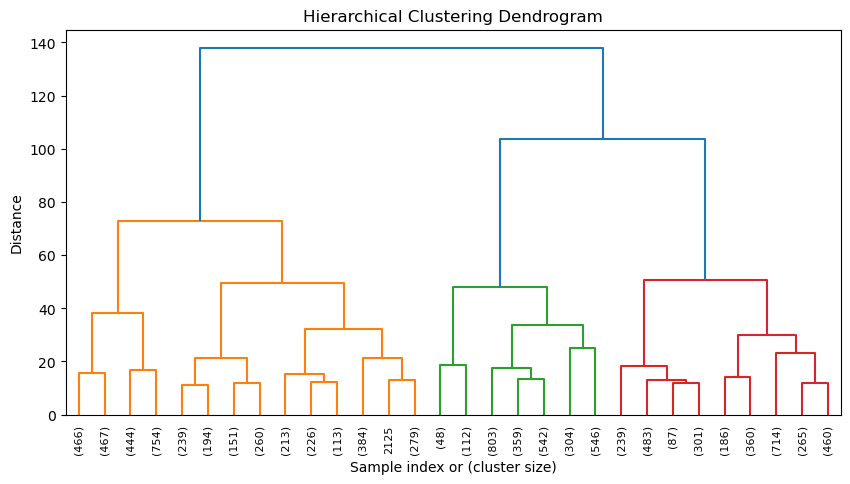

In [76]:
plt.figure(figsize=(10, 5))
# Plot the dendrogram using the linkage matrix
dendrogram(
    linkage_matrix,
    truncate_mode='lastp', # Show only the last 'p' merged clusters
    p=30, # Show the final 30 clusters for better visualization
    leaf_rotation=90.,
    leaf_font_size=8.,
)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index or (cluster size)')
plt.ylabel('Distance')
plt.show()

In [77]:
sil_scores_hc = []
for n_clusters in range(2, 6):
    

    hc_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
    

    sil = silhouette_score(X_pca_sample, hc_labels, random_state=42)
    
    sil_scores_hc.append((n_clusters, sil))
    print(f"k={n_clusters}: Silhouette Score = {sil:.4f}")
for k, score in sil_scores_hc:
    print(f"k={k}: {score:.4f}")


k=2: Silhouette Score = 0.3170
k=3: Silhouette Score = 0.3126
k=4: Silhouette Score = 0.2735
k=5: Silhouette Score = 0.2594
k=2: 0.3170
k=3: 0.3126
k=4: 0.2735
k=5: 0.2594


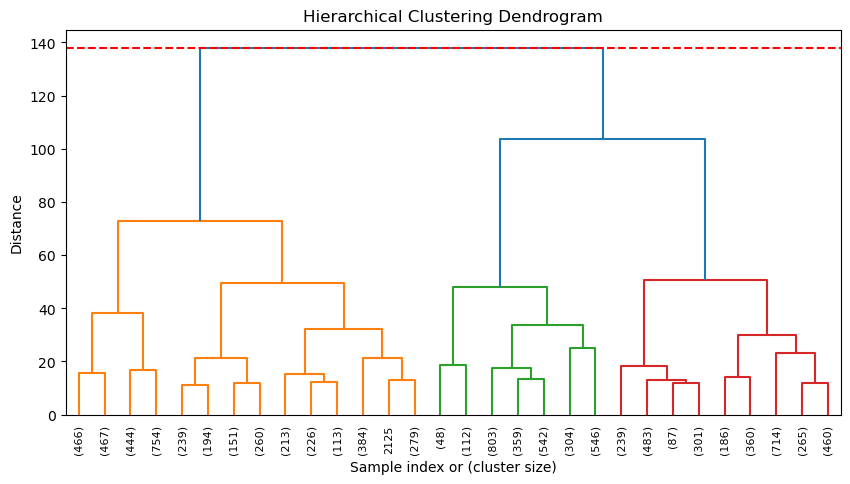

In [78]:
n_clusters = 2
merge_index_to_cut = len(linkage_matrix) - n_clusters + 1
cut_off_distance = linkage_matrix[merge_index_to_cut, 2]

plt.figure(figsize=(10, 5))
# Plot the dendrogram using the linkage matrix
dendrogram(
    linkage_matrix,
    truncate_mode='lastp', # Show only the last 'p' merged clusters
    p=30, # Show the final 30 clusters for better visualization
    leaf_rotation=90.,
    leaf_font_size=8.,
)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index or (cluster size)')
plt.ylabel('Distance')
plt.axhline(y=cut_off_distance, color='r', linestyle='--', label=f'Cut-off for k={n_clusters}')

plt.show()



In [2]:
df_train = pd.read_csv("/Users/simonbruun-simonsen/Desktop/ML-project/data/claims_train.csv")
df_clean = df_train.drop(["IDpol","Region", "VehBrand", "Area"], axis=1)
X_full = df_clean.loc[:, df_clean.columns != 'ClaimNb']

In [3]:
X_full = pd.get_dummies(X_full, columns=["VehGas"],dtype=int)

In [4]:
X_full

,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density,VehGas_Diesel,VehGas_Regular
0,0.43,7,18,36,95,1054,0,1
1,0.10,7,17,80,95,598,0,1
2,0.33,7,3,36,76,4172,0,1
3,0.56,5,4,73,52,15,1,0
4,0.27,8,0,37,50,3021,1,0
...,...,...,...,...,...,...,...,...
542405,0.20,6,10,32,76,1314,1,0
542406,0.06,10,14,34,60,685,1,0
542407,0.34,6,8,32,95,242,1,0
542408,0.72,9,7,39,72,3301,0,1


In [5]:
scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full)

In [6]:
WCSS = []

for i in range(1,30):
  kmeans_pca = KMeans(n_clusters = i, init = "k-means++", random_state = 42)
  kmeans_pca.fit(X_full_scaled)
  WCSS.append(kmeans_pca.inertia_)

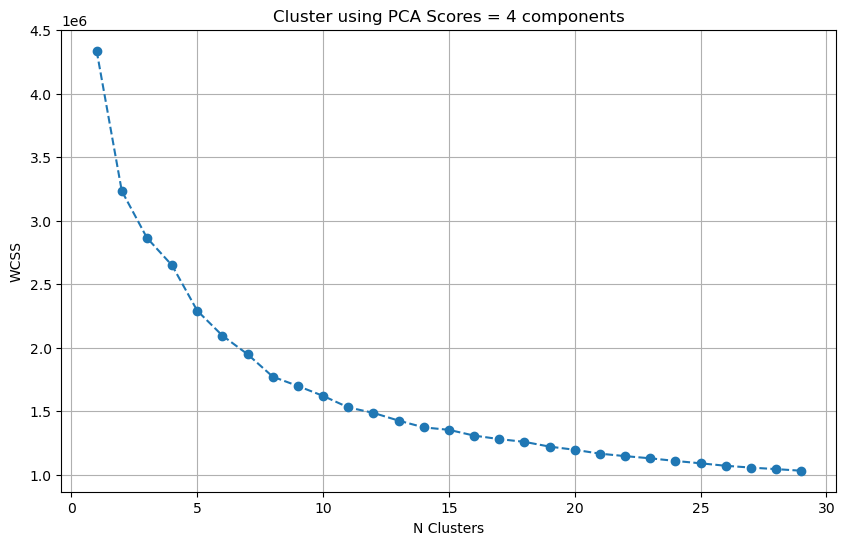

In [7]:
plt.figure(figsize = (10,6))
plt.plot(range(1,30), WCSS, marker = "o", linestyle = "--")
plt.grid()
plt.title("Cluster using PCA Scores = 4 components")
plt.ylabel("WCSS")
plt.xlabel("N Clusters")
plt.show()

In [8]:
sil_scores_full = {}
sample_size = 10000
for n_clusters in range(2,30):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_full_scaled)
    labels = kmeans.labels_
    sil = silhouette_score(X_full_scaled, labels, sample_size=sample_size, random_state=42, metric="correlation")
    sil_scores_full[n_clusters] = sil
    #avg_sil = np.mean(sil_scores)

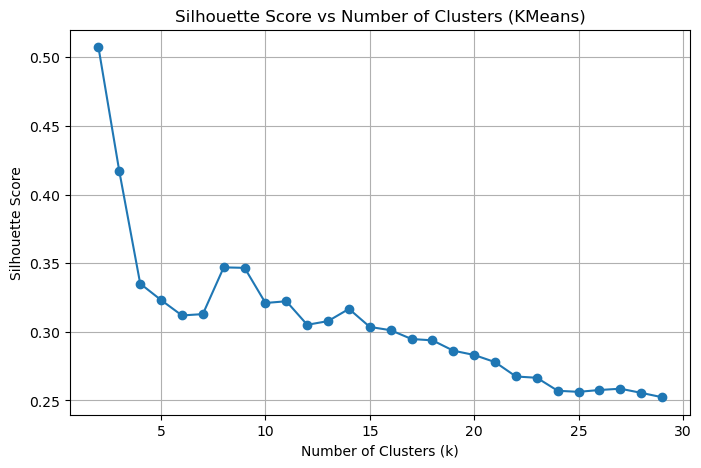

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(list(sil_scores_full.keys()), list(sil_scores_full.values()), marker='o')
plt.title("Silhouette Score vs Number of Clusters (KMeans)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [13]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_full_scaled)
labels = kmeans.labels_
X_full["Label"] = labels

In [14]:
import seaborn as sns

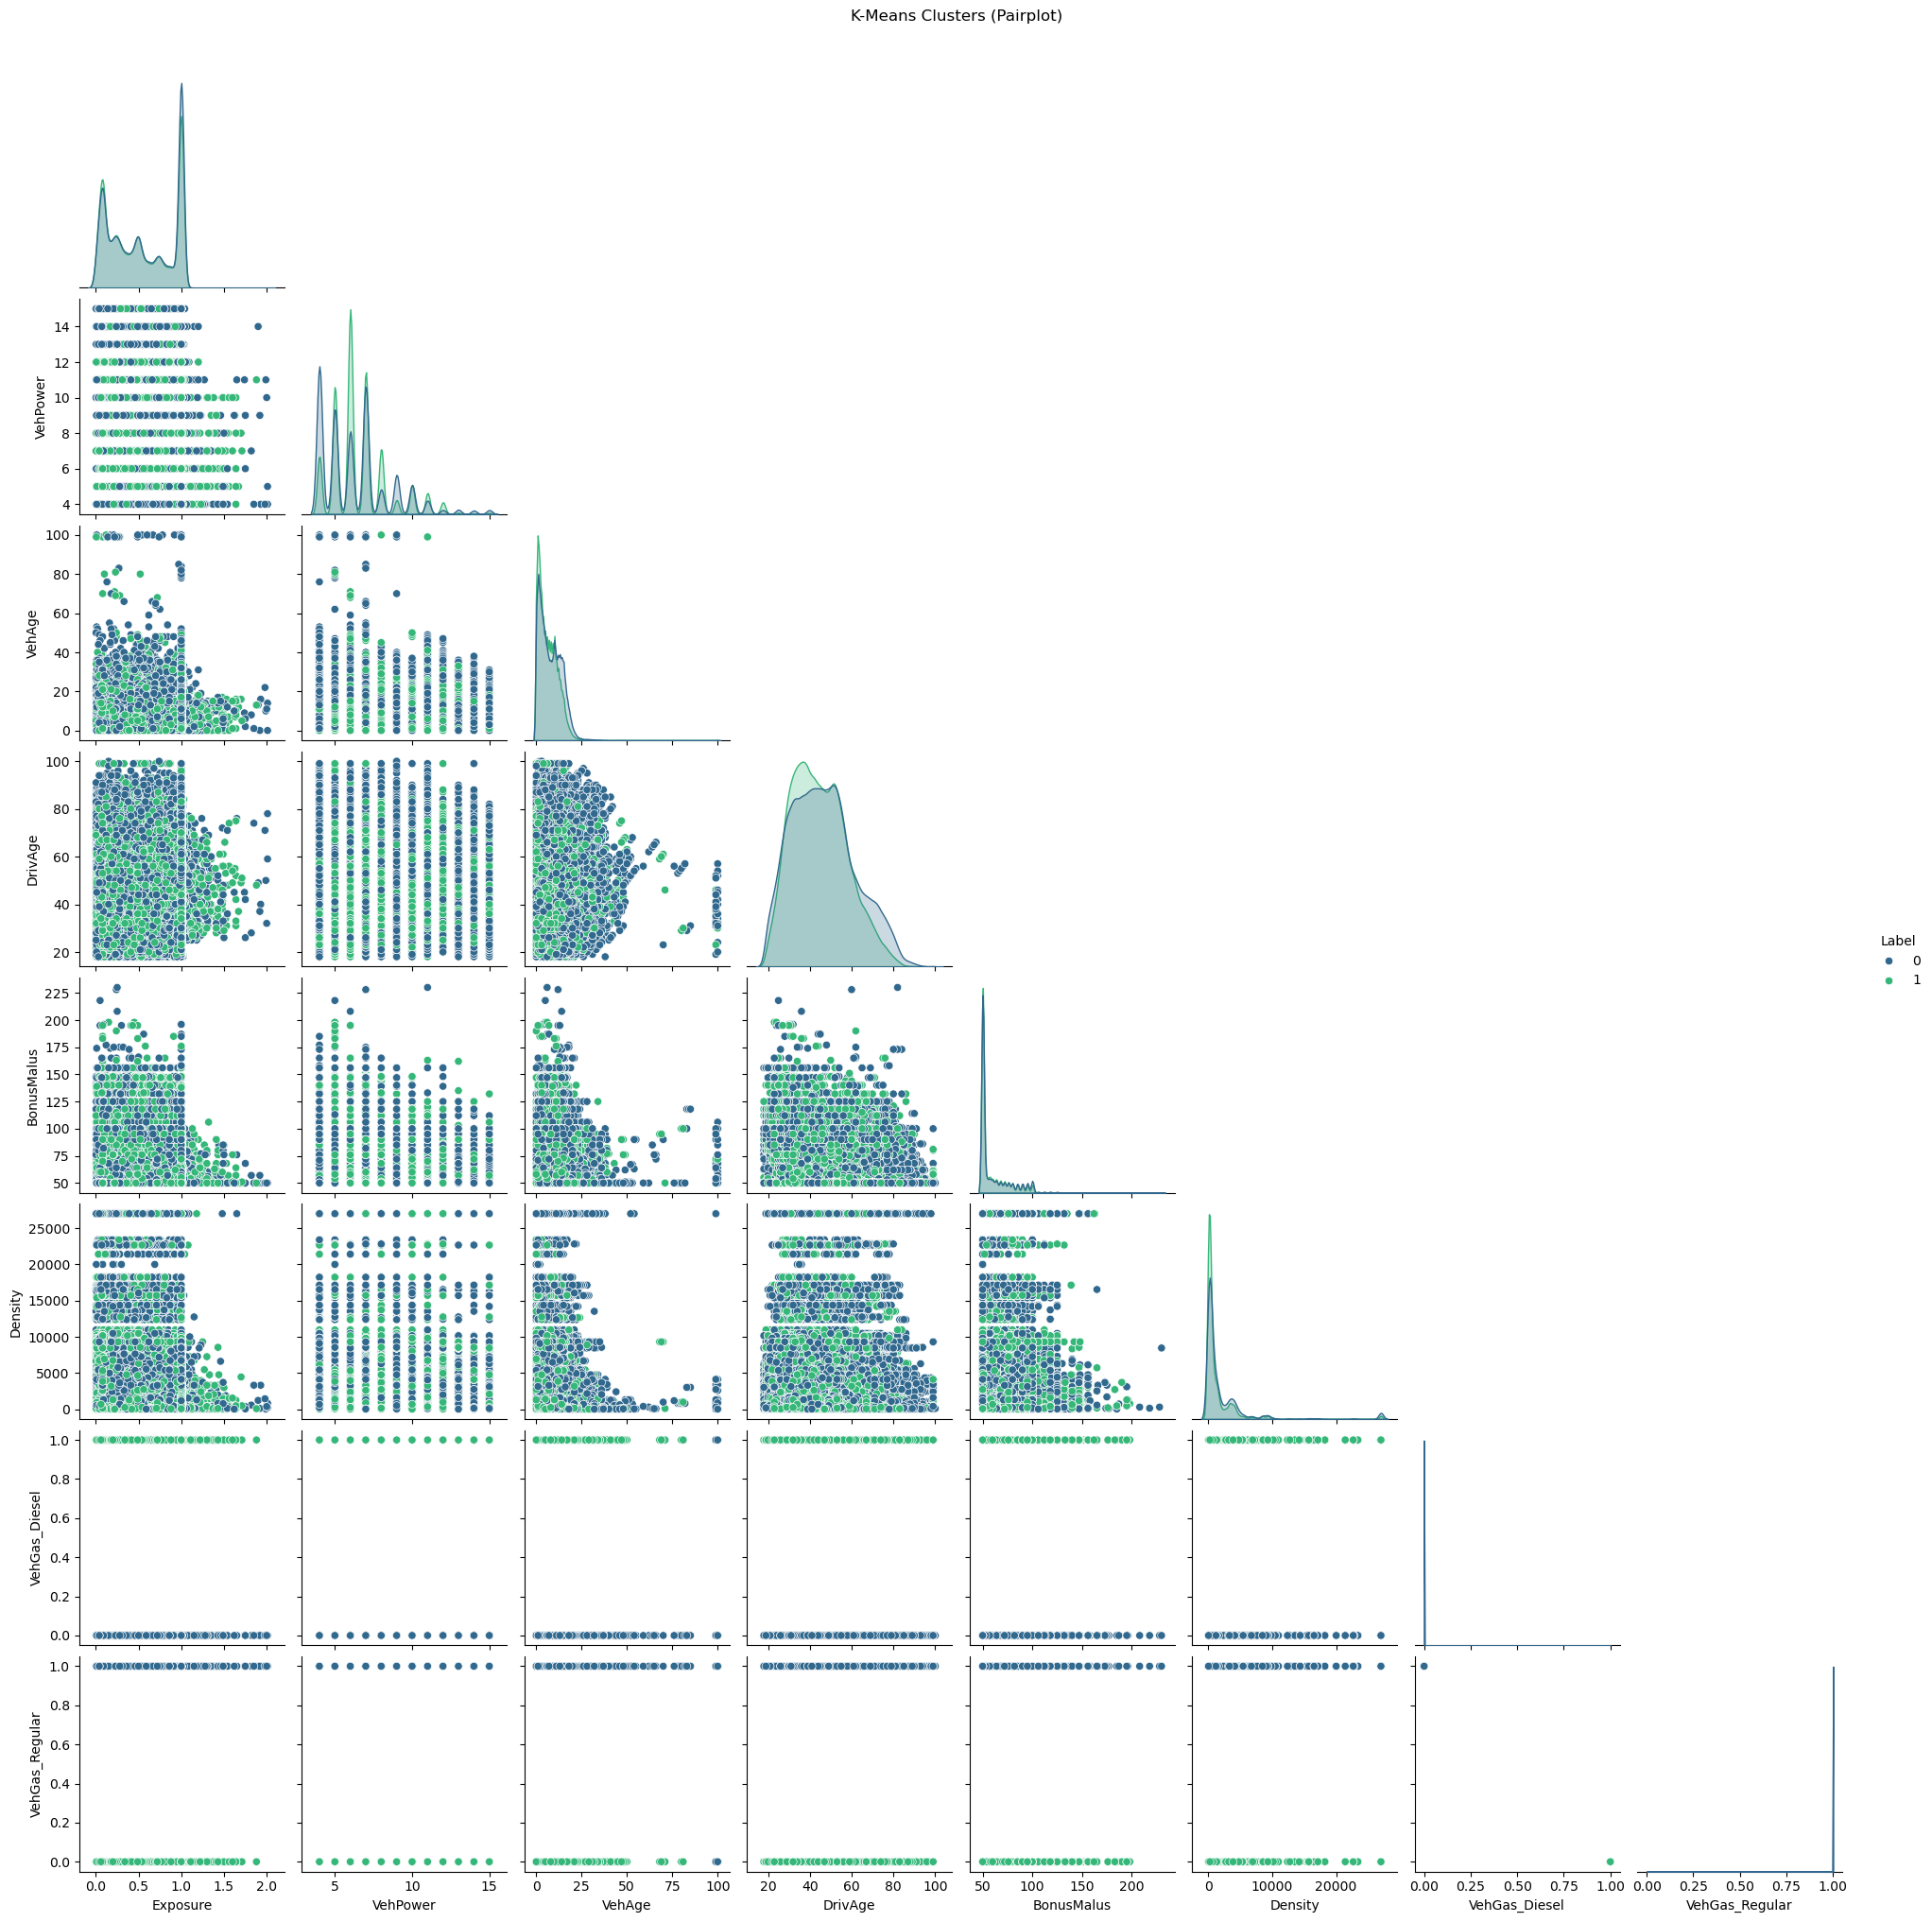

In [15]:
  # add cluster labels

# Pairplot with color by cluster
sns.pairplot(X_full, hue="Label", diag_kind="kde", corner=True, palette="viridis")
plt.suptitle("K-Means Clusters (Pairplot)", y=1.02)
plt.show()

In [43]:
X_full

,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density,VehGas_Diesel,VehGas_Regular,Label
0,0.43,7,18,36,95,1054,0,1,0
1,0.10,7,17,80,95,598,0,1,0
2,0.33,7,3,36,76,4172,0,1,0
3,0.56,5,4,73,52,15,1,0,1
4,0.27,8,0,37,50,3021,1,0,1
...,...,...,...,...,...,...,...,...,...
542405,0.20,6,10,32,76,1314,1,0,1
542406,0.06,10,14,34,60,685,1,0,1
542407,0.34,6,8,32,95,242,1,0,1
542408,0.72,9,7,39,72,3301,0,1,0


In [12]:
X_sample = X_full.sample(n=10000, random_state=42)
X_sample_scaled = scaler.fit_transform(X_sample)

,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density,VehGas_Diesel,VehGas_Regular
388582,0.39,4,1,46,51,345,1,0
147210,0.08,4,3,57,50,4059,0,1
310703,0.65,4,12,72,50,80,1,0
450637,1.00,5,4,28,60,2767,0,1
495721,1.00,5,9,35,76,5449,1,0
...,...,...,...,...,...,...,...,...
404997,0.49,9,31,35,50,30,0,1
327219,1.00,7,2,56,50,2415,0,1
216092,0.49,7,4,65,57,3963,1,0
195304,0.47,6,4,34,68,199,1,0
